In [1]:
import glob
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.path as mpath
import matplotlib.pyplot as plt
from dask.distributed import Client

# Ignore warnings
import warnings
warnings.filterwarnings("ignore", message="Port 8787 is already in use")

# Load grid
grid = xr.open_dataset('/glade/p/cesmdata/cseg/inputdata/share/domains/domain.ocn.tx0.1v2.161014.nc')
grid['tarea'] = grid['area'] / 1e4
grid['tarea'].attrs['units'] = 'm^2'
grid = grid[['xc', 'yc', 'tarea']]

# Make circular boundary for polar stereographic circular plots
theta = np.linspace(0, 2*np.pi, 200)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

# Define the colormap
cmap = plt.colormaps['Blues']

# Set up client
client = Client(n_workers=1, threads_per_worker=8, memory_limit='120GB')
print("Dask dashboard:", client.dashboard_link)

2026-05-19 17:32:29,032 - distributed.nanny.memory - WARNING - Ignoring provided memory limit 120GB due to system memory limit of 10.00 GiB


Dask dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/skygale/proxy/8787/status


**MESACLIP Runs**
- `d651030`: Nominal 1-degree CESM (low-resolution) simulations corresponding to high-resolution experiments (BHIST, BRCP85, PIcntl)
- `d651029`: A 500-year CESM HR pre-industrial control simulation forced with perpetual 1850 conditions (month_1)
- `d651007`: A 10-member ensemble of CESM HR historical (1920-2005) simulations
- `d651009`: A 10-member ensemble of CESM HR RCP 8.5 (2006-2100) simulations

Note: /gdex/data/d651030/BHIST

List of variables: [https://github.com/MESACLIP/cesm-hr-pi-ctrl](https://github.com/MESACLIP/cesm-hr-pi-ctrl-aws?tab=readme-ov-file)

**atm**
- `FSDS`: Downwelling solar flux at surface, W/m2
- `FLDS`: Downwelling longwave flux at surface, W/m2
- `LHFLX`: Surface latent heat flux, W/m2
- `PSL`: Sea level pressure, Pa
- `SHFLX`: Surface sensible heat flux, W/m2
- `TS`: Surface temperature (radiative), K
- `U`: Zonal wind, m/s
- `V`: Meridional wind, m/s

**ice**
- `hi`: Grid cell mean ice thickness, m
- `Tsfc`: Snow/ice surface temperature, K

**ocn**
- `SSH`: Sea surface height, cm

In [3]:
# Base folder
folder = "d651007"
var = "hi"

ensemble_dirs = sorted(glob.glob(f"/gdex/data/{folder}/*ihesp-hires*"))

# Get file lists per ensemble
member_files = []
for ens_dir in ensemble_dirs:
    flist = sorted(glob.glob(f"{ens_dir}/ice/proc/tseries/month_1/*.{var}.*.nc"))
    if flist:
        member_files.append(flist)

member_files = np.array(member_files)

print("Ensembles:", member_files.shape[0])
print("Time chunks per ensemble:", member_files.shape[1])

da = xr.open_dataset(member_files[0, -1], decode_timedelta=True)

# Merge with POP2 hi-res grid
ds = xr.merge(
    [
        da[var].drop_vars(['TLAT', 'TLON', 'ULAT', 'ULON']),
        grid[['xc', 'yc', 'tarea']]
    ],
    compat='override',
    combine_attrs='no_conflicts'
)

# ds['SSH_2'] = ds['SSH_2'].rename({'nlat': 'nj', 'nlon': 'ni'})

ds_to_plot = ds[var].isel(time=-2)
ds_to_plot

Ensembles: 9
Time chunks per ensemble: 9


<xarray.DataArray 'hi' (nj: 2400, ni: 3600)> Size: 35MB
[8640000 values with dtype=float32]
Coordinates:
    time     object 8B 2005-12-01 00:00:00
    xc       (nj, ni) float64 69MB ...
    yc       (nj, ni) float64 69MB ...
Dimensions without coordinates: nj, ni
Attributes:
    units:          m
    long_name:      grid cell mean ice thickness
    cell_measures:  area: tarea
    comment:        ice volume per unit grid cell area
    cell_methods:   time: mean
    time_rep:       averaged

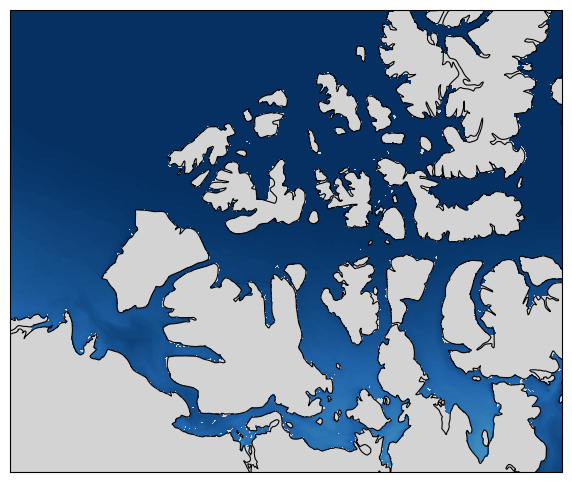

In [30]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.LambertConformal())

# ax.set_extent([-130, -80, 60, 80], crs=ccrs.PlateCarree())
ax.set_extent([-130, -80, 67, 80], crs=ccrs.PlateCarree())

ax.pcolormesh(
    ds['xc'],
    ds['yc'],
    ds_to_plot,
    cmap='RdBu_r',
    transform=ccrs.PlateCarree()
)

ax.set_facecolor('lightgrey')
ax.coastlines(resolution='50m', linewidth=0.8, color='black', zorder=2)
plt.show()

### Plotting

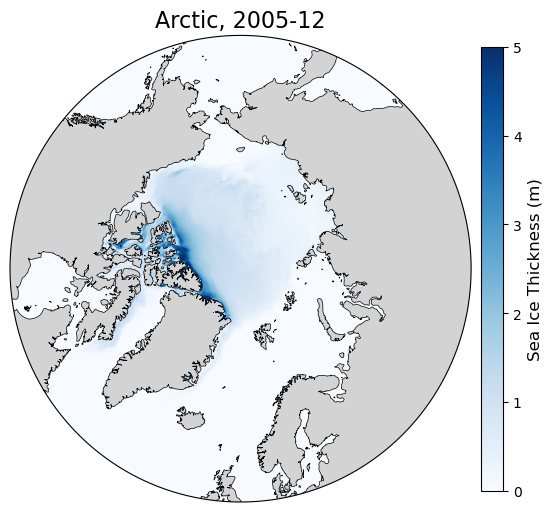

In [10]:
# Set up the figure with a North Polar Stereographic projection
fig = plt.figure(figsize=(14, 14))
ax = fig.add_subplot(1, 2, 1, projection=ccrs.NorthPolarStereo())

ax.set_boundary(circle, transform=ax.transAxes)
ax.set_facecolor('lightgrey')
ax.set_extent([0.005, 360, 54, 90], crs=ccrs.PlateCarree())

# Plot data
this = ax.pcolormesh(
    ds['xc'],
    ds['yc'],
    ds_to_plot,
    cmap=cmap,
    vmin=0,
    vmax=5,
    transform=ccrs.PlateCarree(),
)

ax.coastlines(resolution='50m', linewidth=0.5, color='black', zorder=2)

# Colorbar with title
cbar = plt.colorbar(this, orientation='vertical', fraction=0.045, pad=0.02)
cbar.set_label('Sea Ice Thickness (m)', fontsize=12)

plt.title(f'Arctic, {str(ds_to_plot.time.values)[:7]}', fontsize=16)
plt.show()

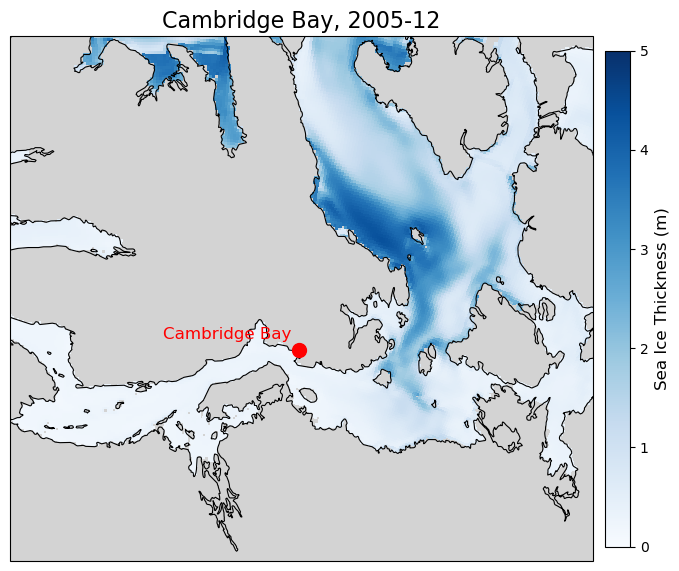

In [11]:
# Cambridge Bay bounding box
cambridge_extent = [-115, -95, 66, 73]  # [lon_min, lon_max, lat_min, lat_max]

# Use Lambert Conformal projection centered near Cambridge Bay
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.LambertConformal(central_longitude=-105, central_latitude=69))

ax.set_facecolor('lightgrey')
ax.set_extent(cambridge_extent, crs=ccrs.PlateCarree())

# Plot
this = ax.pcolormesh(
    ds['xc'],
    ds['yc'],
    ds_to_plot,
    cmap=cmap,
    vmin=0,
    vmax=5,
    transform=ccrs.PlateCarree()
)

ax.coastlines(resolution='10m', linewidth=0.8, color='black', zorder=2)

# Mark Cambridge Bay
ax.plot(-105.1, 69.1, marker='o', color='red', markersize=10, transform=ccrs.PlateCarree(), zorder=4)
ax.text(-110.2, 69.2, 'Cambridge Bay', color='red', fontsize=12, transform=ccrs.PlateCarree())

# Colorbar
cbar = plt.colorbar(this, orientation='vertical', fraction=0.04, pad=0.02)
cbar.set_label('Sea Ice Thickness (m)', fontsize=12)

plt.title(f'Cambridge Bay, {str(ds_to_plot.time.values)[:7]}', fontsize=16)
plt.show()

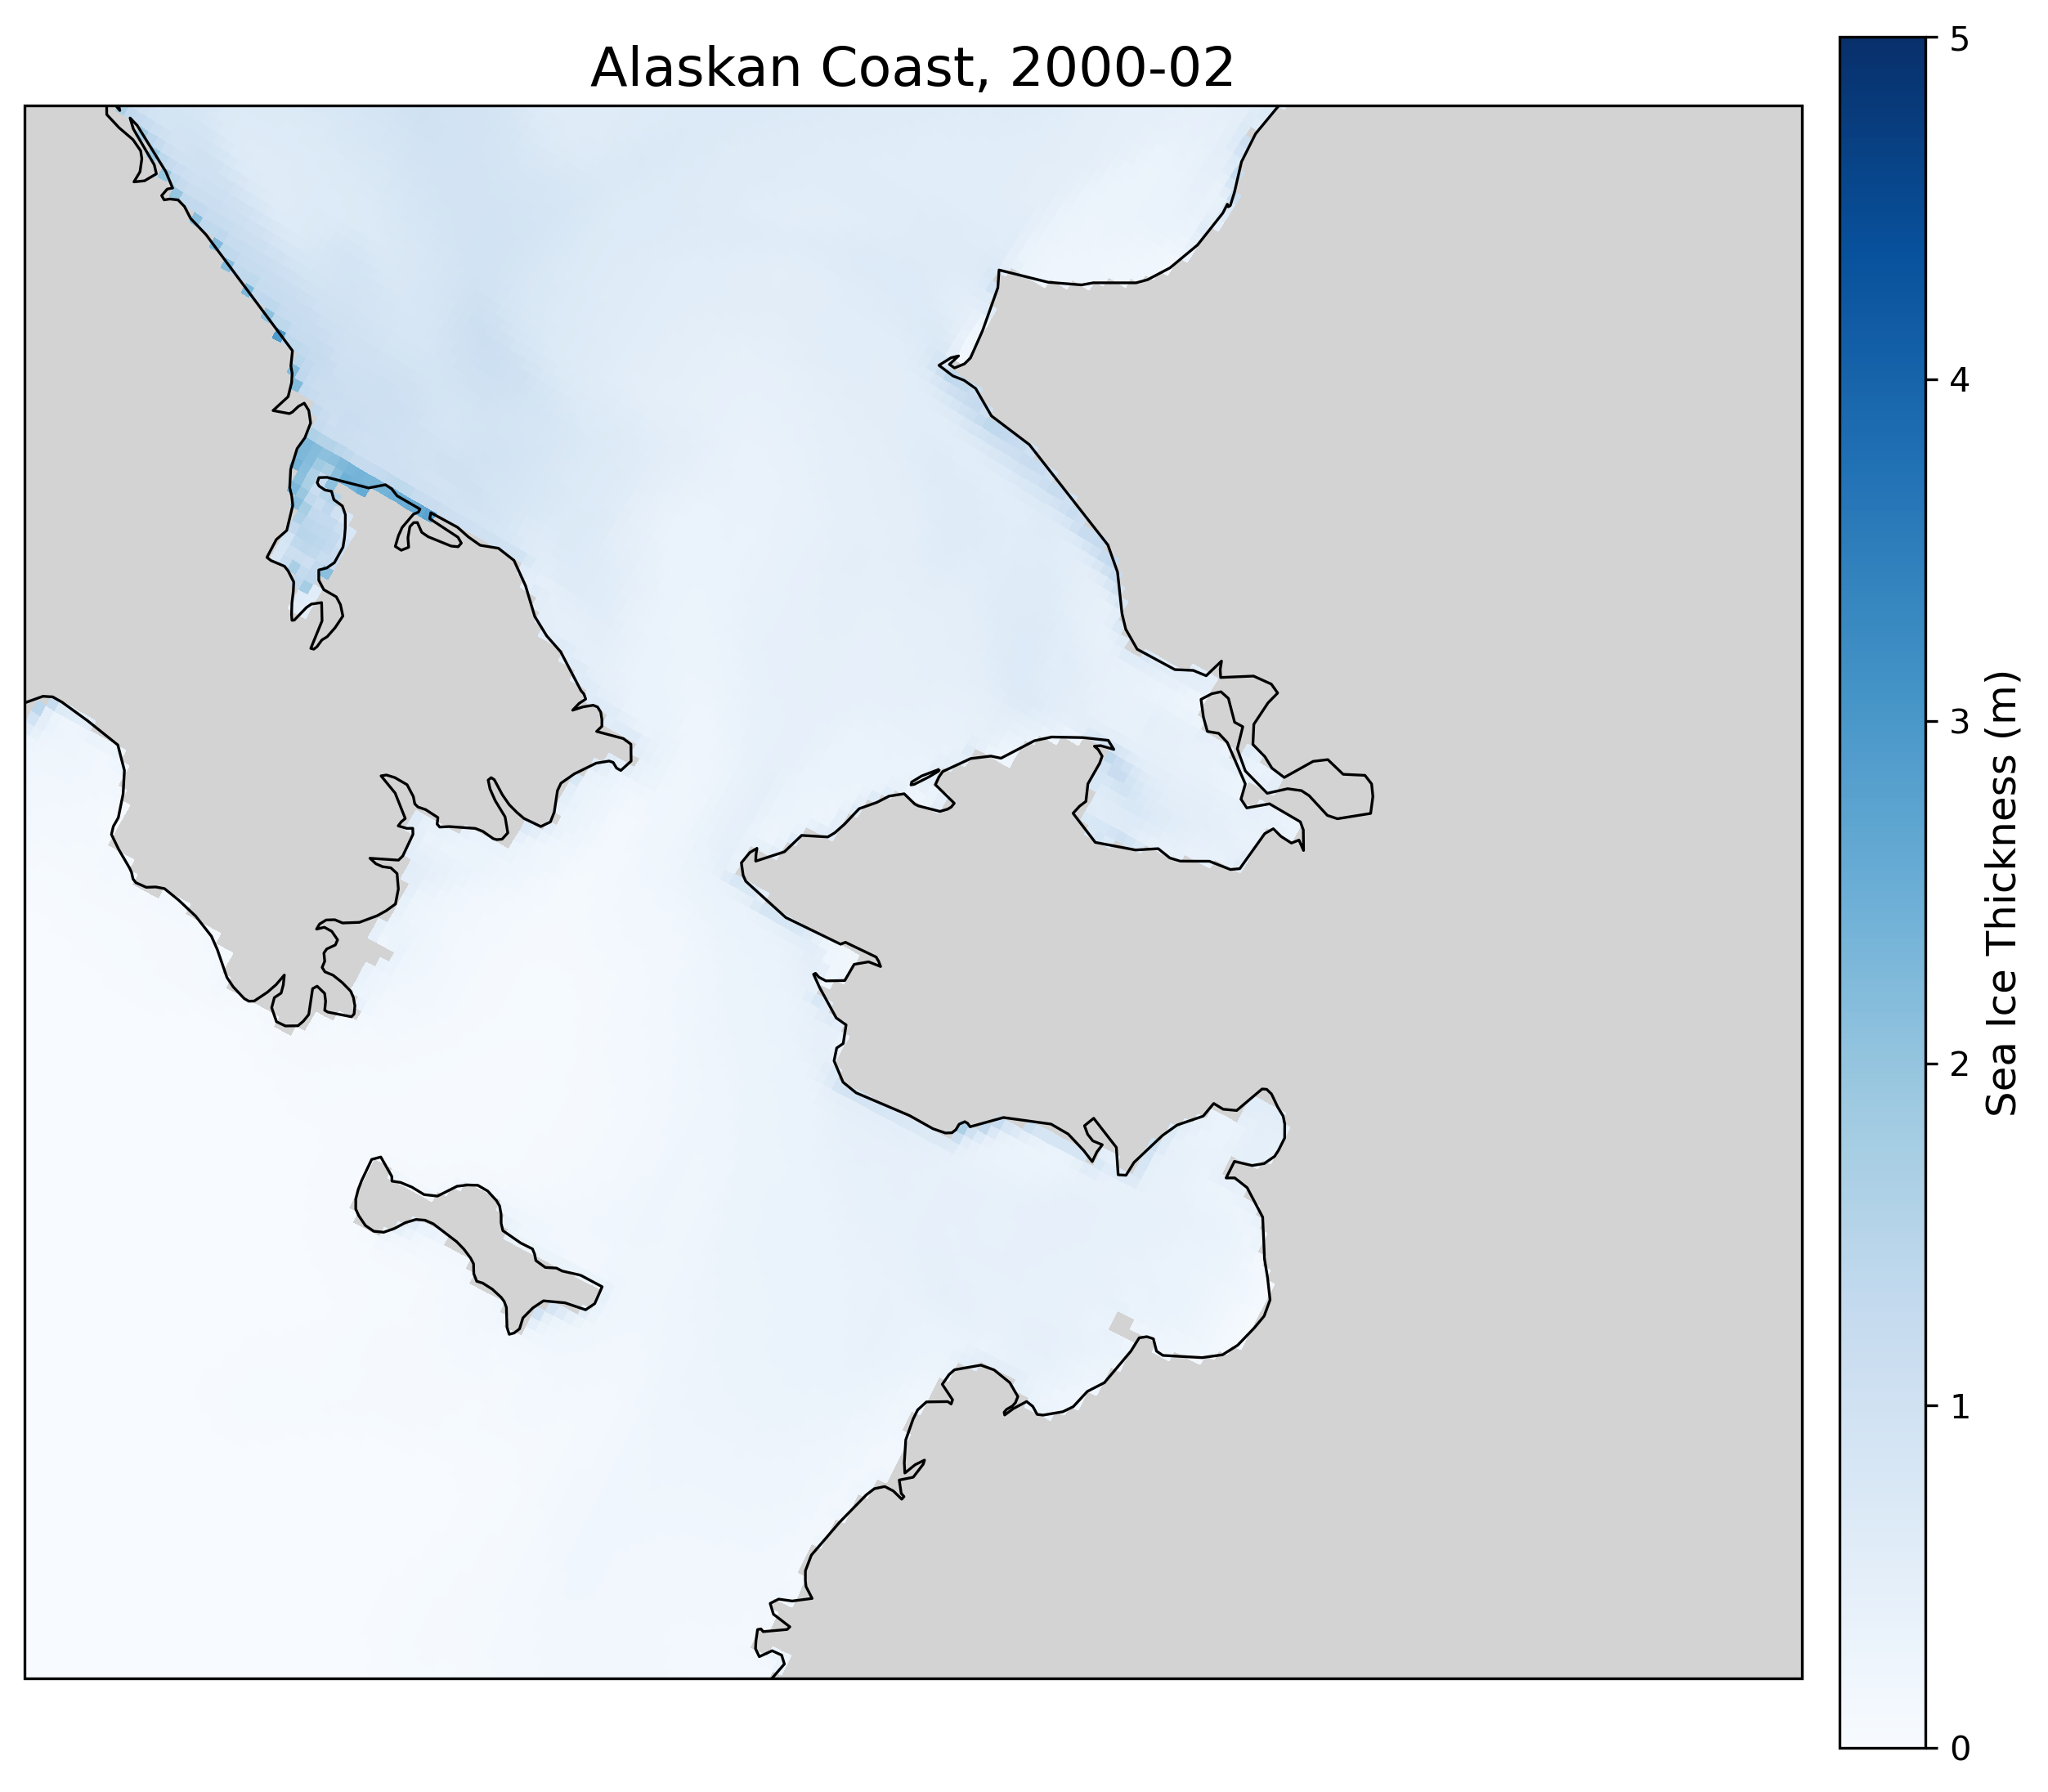

In [44]:
# Alaska bounding box in lon/lat
alaska_extent = [-175, -155, 62, 69]  # [lon_min, lon_max, lat_min, lat_max]

# Use Lambert Conformal projection
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.LambertConformal(central_longitude=-150, central_latitude=60))

ax.set_facecolor('lightgrey')
ax.set_extent(alaska_extent, crs=ccrs.PlateCarree())

# Plot
this = ax.pcolormesh(
    ds['xc'],
    ds['yc'],
    ds_to_plot,
    cmap=cmap,
    vmin=0,
    vmax=5,
    transform=ccrs.PlateCarree()
)

ax.coastlines(resolution='50m', linewidth=0.8, color='black', zorder=2)

# Colorbar
cbar = plt.colorbar(this, orientation='vertical', fraction=0.045, pad=0.02)
cbar.set_label('Sea Ice Thickness (m)', fontsize=12)

plt.title(f'Alaskan Coast, {str(ds_to_plot.time.values)[:7]}', fontsize=16)
plt.show()

### Low Resolution

In [4]:
X = xr.open_dataset('/glade/work/skygale/_projects/SeaIceDownscaling/data/X_hist_buffer.nc').X
ds_to_plot = X.mean(dim='ensemble').isel(channel=0, time=-2)
lon = ((X.lon + 180) % 360) - 180
ds_to_plot = ds_to_plot.assign_coords(lon=lon).sortby('lon')
ds_to_plot

<xarray.DataArray 'X' (lat: 21, lon: 51)> Size: 4kB
array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 8.2182510e-09,
        2.2863881e-08, 3.7025288e-06],
       ...,
       [2.1591172e+00, 2.2186100e+00, 2.2773051e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [2.0059810e+00, 2.0431514e+00, 2.0828638e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00],
       [1.9377512e+00, 1.9618318e+00, 1.9874516e+00, ..., 0.0000000e+00,
        0.0000000e+00, 0.0000000e+00]], dtype=float32)
Coordinates:
    time     object 8B 2005-12-01 00:00:00
  * lat      (lat) float64 168B 60.0 61.0 62.0 63.0 64.0 ... 77.0 78.0 79.0 80.0
    channel  int64 8B 0
  * lon      (lon) float64 408B -130.0 -129.0 -128.0 ... -82.0 -81.0 -80.0

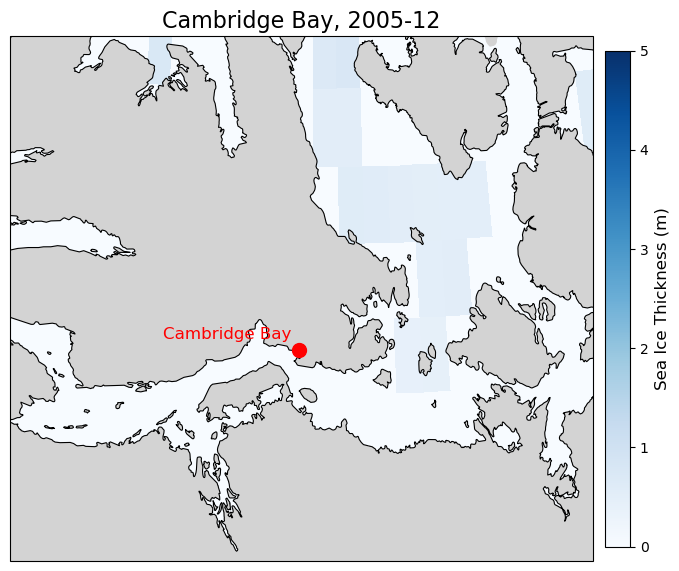

In [14]:
import cartopy.feature as cfeature

# Cambridge Bay bounding box
cambridge_extent = [-115, -95, 66, 73]  # [lon_min, lon_max, lat_min, lat_max]

# Use Lambert Conformal projection centered near Cambridge Bay
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.LambertConformal(central_longitude=-105, central_latitude=69))

ax.set_extent(cambridge_extent, crs=ccrs.PlateCarree())
ax.add_feature(
    cfeature.LAND,
    facecolor='lightgrey',
    edgecolor='none',
    zorder=2
)

# Plot
this = ax.pcolormesh(
    ds_to_plot.lon,
    ds_to_plot.lat,
    ds_to_plot,
    cmap=cmap,
    vmin=0,
    vmax=5,
    transform=ccrs.PlateCarree()
)

ax.coastlines(resolution='10m', linewidth=0.8, color='black', zorder=6)

# Mark Cambridge Bay
ax.plot(-105.1, 69.1, marker='o', color='red', markersize=10, transform=ccrs.PlateCarree(), zorder=8)
ax.text(-110.2, 69.2, 'Cambridge Bay', color='red', fontsize=12, transform=ccrs.PlateCarree(), zorder=8)

# Colorbar
cbar = plt.colorbar(this, orientation='vertical', fraction=0.04, pad=0.02)
cbar.set_label('Sea Ice Thickness (m)', fontsize=12)

plt.title(f'Cambridge Bay, {str(ds_to_plot.time.values)[:7]}', fontsize=16)
plt.show()